In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import zarr
import ast
import random

import numpy as np
import pandas as pd
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import sys
sys.path.insert(0, str(Path.cwd().parent / "pangaea-bench"))

from pangaea.datasets.zeroflood import ZeroFlood
from utils import viz_lon_lat_heatmap, calc_confusion_matrix

# Metadata

In [3]:
root = os.path.join(os.environ.get('SCRATCH'),'zeroflood','ZeroFlood')

train_val_df = pd.read_csv(os.path.join(root, 'metadata', 'info_train.csv'), delimiter='\t')
val_len = len(train_val_df)//5       # Train:Val = 8:2

train_df = train_val_df.iloc[:-val_len].reset_index(drop=True)
val_df = train_val_df.iloc[-val_len:].reset_index(drop=True)
test_df = pd.read_csv(os.path.join(root, 'metadata', 'info_val.csv'), delimiter='\t')

len(train_df), len(val_df) , len(test_df)


(20868, 5217, 226)

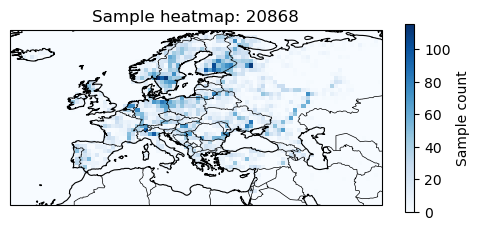

In [4]:
viz_lon_lat_heatmap(train_df)

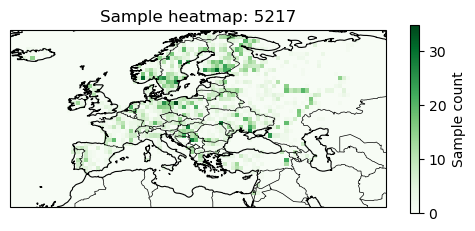

In [5]:
viz_lon_lat_heatmap(val_df, cmap='Greens')

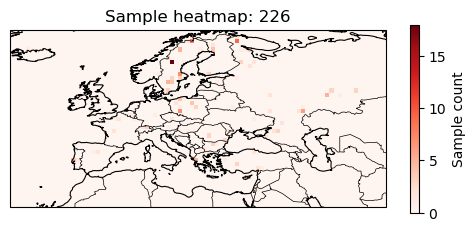

In [6]:
viz_lon_lat_heatmap(test_df, cmap='Reds')

---------------------------------
train: Water body in Risk Zone

mean : 0.7548025419914453
std : 0.26655501034846946
median : 0.8731085279717729

min : 0.04867637123026841 (17243)
max : 1.0 (2235)
---------------------------------


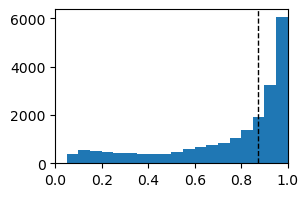

In [8]:
_ = calc_confusion_matrix(train_df, 'train', figsize=(3,2))

---------------------------------
val: Water body in Risk Zone

mean : 0.7516616074335026
std : 0.2699537936968732
median : 0.8687914677249333

min : 0.050748982862778944 (1665)
max : 1.0 (161)
---------------------------------


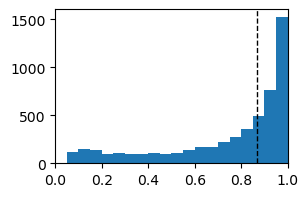

In [9]:
_ = calc_confusion_matrix(val_df, 'val', figsize=(3,2))

---------------------------------
test: Water body in Risk Zone

mean : 0.7860971298895754
std : 0.25094473597551453
median : 0.9006448002708214

min : 0.0660950447652664 (108)
max : 0.9992140034838765 (11)
---------------------------------


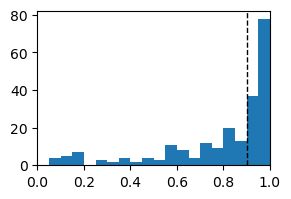

In [10]:
_ = calc_confusion_matrix(test_df, 'test', figsize=(3,2))

# pangaea/datasets/zeroflood

In [11]:
train_dataset = ZeroFlood(
    dataset_name = 'ZeroFlood', split = 'train', root_path = root, 
    img_size = 264, constant_scale = 1,
    num_classes = 2, classes = ['null', 'flood_rp10'], ignore_index = -1,
    bands = {'sar': ['VV','VH']},
    distribution = [0.66, 0.34],
    data_mean = {'sar': [-11.75303324, -17.50780573]},
    data_std = {'sar': [5.03739141, 4.57518098]},
    data_max = {'sar': [42.3125, 40.8125]},
    data_min = {'sar': [-56.15625, -61.3125]},
    multi_modal = False, multi_temporal = False, download_url = None, auto_download = False,
)

val_dataset = ZeroFlood(
    dataset_name = 'ZeroFlood', split = 'val', root_path = root, 
    img_size = 264, constant_scale = 1,
    num_classes = 2, classes = ['null', 'flood_rp10'], ignore_index = -1,
    bands = {'sar': ['VV','VH']},
    distribution = [0.66, 0.34],
    data_mean = {'sar': [-11.75303324, -17.50780573]},
    data_std = {'sar': [5.03739141, 4.57518098]},
    data_max = {'sar': [42.3125, 40.8125]},
    data_min = {'sar': [-56.15625, -61.3125]},
    multi_modal = False, multi_temporal = False, download_url = None, auto_download = False,
)

test_dataset = ZeroFlood(
    dataset_name = 'ZeroFlood', split = 'test', root_path = root, 
    img_size = 264, constant_scale = 1,
    num_classes = 2, classes = ['null', 'flood_rp10'], ignore_index = -1,
    bands = {'sar': ['VV','VH']},
    distribution = [0.66, 0.34],
    data_mean = {'sar': [-11.75303324, -17.50780573]},
    data_std = {'sar': [5.03739141, 4.57518098]},
    data_max = {'sar': [42.3125, 40.8125]},
    data_min = {'sar': [-56.15625, -61.3125]},
    multi_modal = False, multi_temporal = False, download_url = None, auto_download = False,
)

print(f"Train: {len(train_dataset)} \t Val: {len(val_dataset)} \t Test: {len(test_dataset)}")

Train: 20868 	 Val: 5217 	 Test: 226
